# ⚡ Model Monitor — Kaggle Gym Battle Tracker 🔴

*Gotta ship 'em all!* Every shipped agent is a trainer on the Kaggle ladder;
this notebook pulls their live battle records and tracks **leaderboard score**
and **rolling win rate** over time — per model AND per **deck**.

Pulls the episode listings for every submission in `MODELS` (via
`rl.kaggle_ingest.list_episodes` — needs `~/.kaggle/kaggle.json` credentials),
labels each episode with its model, and resolves each model's **real deck from
a live replay** (cell 2 — never trust file names or labels for this; the M18
post-ship surprise was that M16+ ship the water deck whose ace is Mega
Abomasnow ex, not lucario). Deck sprites carry that identity through the
tiles, the Pokédex, and every line end in charts 1, 2 and 4. Re-run all cells
to refresh — listings cache per submission to `data/kaggle/listings/`
(gitignored; retired models are served from disk, only a submission still
battling in the last 3 days is refetched) and replays cache to
`data/kaggle/raw/`. Delete a listing parquet to force a refetch. Add a row to
`MODELS` whenever a new agent ships.

**Trainer tips 🎒** — the charts are interactive:
- **hover** any point for the battle report,
- **click** a legend entry to hide that model, **double-click** it to isolate,
- **drag** to zoom (double-click the plot to reset),
- chart 1 has **range buttons + a range slider**, chart 2 has
  **rolling-window buttons**, chart 4 groups battles by **deck**,
- each model's newest battle wears its **ace sprite** in charts 1 and 2 — the
  deck read off a live replay, not off the label.

In [ ]:
import base64
import sys
from pathlib import Path

# repo-root bootstrap: the kernel's cwd is notebooks/
_ROOT = Path.cwd()
while not (_ROOT / "rl").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import polars as pl

from rl.kaggle_ingest import list_episodes

# Listing cache — one parquet per submission under data/kaggle/ (gitignored).
# A retired submission's listing never changes, so it is served from disk with
# zero network calls; only a listing whose newest episode is within
# LIVE_WINDOW (the submission may still be battling) is refetched.
# ListEpisodes is not incremental — a refresh is one full call — but this
# drops the calls for every retired model, which is what kept tripping
# Kaggle's 429 rate limit as the ship history grew.
LISTINGS_DIR = _ROOT / "data" / "kaggle" / "listings"
LISTINGS_DIR.mkdir(parents=True, exist_ok=True)
LIVE_WINDOW = pd.Timedelta(days=3)


def load_listing(sid: int) -> pl.DataFrame:
    path = LISTINGS_DIR / f"{sid}.parquet"
    if path.exists():
        cached = pl.read_parquet(path)
        if len(cached):
            times = cached.select(pl.col("end_time")
                                  .fill_null(pl.col("create_time"))
                                  ).to_series().to_list()
            newest = pd.to_datetime(times, format="mixed", utc=True).max()
            if pd.Timestamp.now(tz="UTC") - newest > LIVE_WINDOW:
                return cached
    fresh = list_episodes(submission_id=sid)
    if len(fresh):
        fresh.write_parquet(path)
    return fresh


# Ship history: submission id -> model label (docs/MILESTONES.md ship history).
MODELS = {
    54586430: "M7.4a: solver-on (rules)",
    54616196: "M7.5: partial fixes (rules)",
    54621283: "M7.5: solver+5fixes (rules)",
    54779834: "M11: osv3_plan0c (neural)",
    54790886: "M14: osv3_plan2 (setup-plans)",
    54793851: "M15: osv3h_plan1 (hand-aware)",
    54801291: "M16: osv3o_plan1 (option-identity)",
    54817441: "M18: osv3o_plan5 (value-teacher-fixed)",
    54817813: "M18.1: osv3o_plan5+lucario (M18.1 deck fix)",
    54836093: "M20: ppo_best_m20legB+lucario (M20 PPO+KL-anchor)",
    54846434: "M21.B2: encoder-v4 (opponent memory) + plan-PPO + meta-mixture PPO",
    54849475: "M21.B3: KL-annealed-to-0 self-play + guided gust exploration",
    54864089: "M22c: Self-learn neural net post arch change",
    54864190: "M22c (Correct): Self learn with correct lucario deck",
    54885173: "M24: replay-BC clone (teacher 54618168@1251, Alakazam deck)",
    54886232: "M12: replay-derived Lucario V2 - expert fallback + deck preservation + Crustle/Drednaw/NZ counters",
    54897966: "M25: hand-aware ids (m25_bc_alakazam_v3h) + clone deck",
    54903635: "M26: O1 telepath-priority rule on m25_bc_alakazam_v3h + clone deck",
    54914673: "M29: pooled same-deck winner demonstrations (783 games, 8 teachers) + O1",
    54929991: "M30: gac overrides (telepath,deckguard,ash,conserve) on m28_winners + clone deck",
    54935640: "M31: + O7 poffinfloor bench-economy rule (gacb) on m28_winners + clone deck",
    54997669: "M33: alakazam_v2 setup-speed deck-tech (m28_winners pilot)",
    55011605: "M35: gacf — drop poffinfloor, add benchfloor on m28_winners + alakazam_v2",
    55030954: "M36: alakazam_v2_h4 hammer-4 wall tech (+1 Enhanced Hammer −1 Hilda) on m28_winners + gacf",
    55065484: "M37: gacfr3 — O12d racemode3 wall-family blanket conserve on m28_winners + alakazam_v2_h4",
    55146658: "M38: m38_w9294_cont3 — champion + 1ep 800-1058-band same-deck winners, gacfr3 + alakazam_v2_h4",
    55172160: "M39 Ship A: cont3 + conserve-only (gacfr3 stripped to `conserve`) + alakazam_v2_h4",
    55182097: "M39 Ship B: cont3 + conserve,racemode2,racemode4 (anti-deck-out package) + alakazam_v2_h4",
    55185485: "M40 floor: m39_retain_b (corpus-B + champion retention) + conserve,racemode2,racemode4 + alakazam_v2_h4",
    55216935: "M40b r1 Ship 1: cont3 + conserve,planzero,ash,ashguard (racemode dropped; Sacred-Ash window O5+O15)",
    55216941: "M40b r1 Ship 2: m40_top1000 (1000+ own-list mirror fine-tune) + conserve,planzero,ash,ashguard",
    55221491: "M41 ogerpon: m41_ogerpon on decks/ogerpon.csv (47 seats / 3.3k decisions) — FIRST DECK SWITCH; rerankers inert on this deck, effectively planzero",
    55265099: "M41b alakazam: m41b_wide_prod — encoder WIDTH 143, the M41+M42+M41b blocks trained for the first time (+6.17pp z=8.77 vs cont3 offline; width part +2.78pp, replicated 3/3 seeds)",
    55265105: "M41b ogerpon: m41_ogerpon UNCHANGED — concurrent two-deck live read against 55265099; every ogerpon retrain regressed (-5.35pp at 14ep, -11.48pp at 2ep) so the proven net ships",
    55464234: "M43 alakazam: ppo_best_m43a_base — the campaign's FIRST honest-PPO ship (50x400 outcome PPO, KL 0.1 to frozen start, retain_b critic; +3.72pp z=5.93 vs m41b_wide_prod on the 25-bed r1 gate, wall_d1 +19.75pp) + conserve,racemode2,racemode4,planzero + alakazam_v2_h4",
}

# Validated categorical palette (dataviz skill validator, light surface, all
# checks pass). Color follows the MODEL identity, in fixed ship order; never
# re-assigned when filtering. 9th ship reuses slot 0 (blue), 10th reuses slot 1
# (green) — separable from the earlier ships, which no longer battle.
PALETTE = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834",
           "#7a5cd6", "#a35a14"]
COLOR = {sid: PALETTE[i % len(PALETTE)] for i, sid in enumerate(MODELS)}
INK, INK2, GRID, SURFACE = "#333333", "#666666", "#e5e5e5", "#fcfcfb"

# Deck identity (REAL, not a gimmick — resolved from live replays in the next
# cell). Keyed by decks/<name>.csv stem; the ace is what you see in replays.
# Deck colors #2a78d6/#a35a14 validated as a pair (CVD ΔE 27.0, all PASS);
# sprites + direct labels carry identity as secondary encoding.
def _sprite_b64(name):
    p = _ROOT / "notebooks" / "sprites" / f"{name}.png"
    return ("data:image/png;base64,"
            + base64.b64encode(p.read_bytes()).decode()) if p.exists() else None

DECK_META = {
    "lucario": dict(ace="Mega Lucario ex", type="fighting", emoji="🥊",
                    color="#a35a14", sprite=_sprite_b64("lucario")),
    "kyogre": dict(ace="Mega Abomasnow ex", type="water", emoji="🌊",
                   color="#2a78d6", sprite=_sprite_b64("abomasnow")),
    "clone54618168": dict(ace="Alakazam (clone)", type="psychic",
                          emoji="🔮", color="#7a5cd6",
                          sprite=_sprite_b64("alakazam")),
    "alakazam_v2": dict(ace="Alakazam (v2 setup)", type="psychic",
                        emoji="🪄", color="#c94fc9",
                        sprite=_sprite_b64("alakazam")),
    "alakazam_v2_h4": dict(ace="Alakazam (h4 hammer)", type="psychic",
                           emoji="🔨", color="#8e44ad",
                           sprite=_sprite_b64("alakazam")),
    # M41 — the campaign's first deck switch. One Basic attacker, one
    # energy type, no evolution line: the property that made it clone well
    # from a 3.3k-decision corpus (docs/M41.md).
    "ogerpon": dict(ace="Teal Mask Ogerpon ex", type="grass", emoji="🌿",
                    color="#3c8a2e", sprite=_sprite_b64("ogerpon")),
    "unknown": dict(ace="?", type="?", emoji="❓", color=INK2, sprite=None),
}


def ace_sprite_image(sid, x, y, x_span_ms, y_span, scale=0.055):
    """Layout-image dict: the deck's ace riding a model line's newest point.

    Anchored in DATA coordinates (xref/yref = x/y) so the sprite tracks its
    point through zoom and pan. sizex is in milliseconds (date axis), sizey in
    y-units; sizing="contain" fits the sprite inside that box at its native
    aspect. DECKS comes from the replay audit in the next cell — read at call
    time, so this stays honest about which deck actually shipped.
    """
    sprite = DECK_META[DECKS[sid]]["sprite"]
    if sprite is None or pd.isna(y):
        return None
    return dict(source=sprite, xref="x", yref="y",
                x=x.isoformat(), y=float(y),
                xanchor="center", yanchor="middle", layer="above",
                sizex=x_span_ms * scale, sizey=y_span * scale * 3,
                sizing="contain")


def x_span_ms(times, pad=0.03):
    """(span in ms, right-edge pad) for a time series — pad keeps the sprite
    on the newest point from being clipped at the plot edge."""
    span = (times.max() - times.min()).total_seconds() * 1e3 or 1e3
    return span, pd.Timedelta(milliseconds=span * pad)


# Pokedex plotly template: recessive grid/axes, ink-colored text, thin marks.
pio.templates["pokedex"] = go.layout.Template(layout=dict(
    font=dict(family="Segoe UI, Helvetica, Arial, sans-serif", size=12,
              color=INK2),
    title=dict(font=dict(size=15, color=INK), x=0, xanchor="left"),
    paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
    xaxis=dict(gridcolor=GRID, linecolor=GRID, zeroline=False,
               ticks="outside", tickcolor=GRID),
    yaxis=dict(gridcolor=GRID, linecolor=GRID, zeroline=False),
    legend=dict(borderwidth=0, font=dict(size=11)),
    hoverlabel=dict(bgcolor="#ffffff", bordercolor=GRID,
                    font=dict(color=INK, size=11)),
    margin=dict(l=60, r=30, t=70, b=40),
    colorway=PALETTE,
))
pio.templates.default = "pokedex"

In [12]:
# 🎴 Deck audit — read each model's ACTUAL deck off one live replay.
# Never trust file names or labels for this (M1 lesson, re-learned in M18:
# since M16 the bundles ship decks/kyogre.csv, whose ace is Mega Abomasnow
# ex, while every earlier ship played lucario). Listings come from the
# load_listing cache and replays cache to data/kaggle/raw/, so retired
# models resolve with zero network calls.
from rl.kaggle_ingest import fetch_episode, parse_episode

REF_DECKS = {f.stem: sorted(int(x) for x in f.read_text().split() if x.strip())
             for f in (_ROOT / "decks").glob("*.csv")}


def resolve_deck(sid: int) -> str:
    eps = load_listing(sid).to_dicts()
    if not eps:
        return "unknown"
    ep = eps[len(eps) // 2]                    # a mid-run episode
    parsed = parse_episode(fetch_episode(ep["episode_id"]),
                           our_submission_ids=[sid],
                           episode_id=ep["episode_id"])
    # replays don't serialize per-seat submission ids -> seat from the listing
    seat = parsed.our_seat
    if seat is None:
        seat = 0 if ep.get("submission_id_0") == sid else 1
    deck = parsed.decks[seat]
    if deck is None:
        return "unknown"
    deck = sorted(deck)
    return next((k for k, v in REF_DECKS.items() if v == deck), "unknown")


DECKS = {sid: resolve_deck(sid) for sid in MODELS}
DECK_EMOJI = {sid: DECK_META[DECKS[sid]]["emoji"] for sid in MODELS}
DEX = {sid: f"{DECK_EMOJI[sid]} {label}" for sid, label in MODELS.items()}
for sid, label in MODELS.items():
    meta = DECK_META[DECKS[sid]]
    print(f"{meta['emoji']} {label}: {DECKS[sid]}.csv — ace {meta['ace']}")

🥊 M7.4a: solver-on (rules): lucario.csv — ace Mega Lucario ex
🥊 M7.5: partial fixes (rules): lucario.csv — ace Mega Lucario ex
🥊 M7.5: solver+5fixes (rules): lucario.csv — ace Mega Lucario ex
🥊 M11: osv3_plan0c (neural): lucario.csv — ace Mega Lucario ex
🥊 M14: osv3_plan2 (setup-plans): lucario.csv — ace Mega Lucario ex
🥊 M15: osv3h_plan1 (hand-aware): lucario.csv — ace Mega Lucario ex
🌊 M16: osv3o_plan1 (option-identity): kyogre.csv — ace Mega Abomasnow ex
🌊 M18: osv3o_plan5 (value-teacher-fixed): kyogre.csv — ace Mega Abomasnow ex
🥊 M18.1: osv3o_plan5+lucario (M18.1 deck fix): lucario.csv — ace Mega Lucario ex
🥊 M20: ppo_best_m20legB+lucario (M20 PPO+KL-anchor): lucario.csv — ace Mega Lucario ex
🥊 M21.B2: encoder-v4 (opponent memory) + plan-PPO + meta-mixture PPO: lucario.csv — ace Mega Lucario ex
🥊 M21.B3: KL-annealed-to-0 self-play + guided gust exploration: lucario.csv — ace Mega Lucario ex
🌊 M22c: Self-learn neural net post arch change: kyogre.csv — ace Mega Abomasnow ex
🥊 M22c (

In [13]:
def fetch_model(sub_id: int, label: str) -> pd.DataFrame:
    """One row per episode, from OUR seat's perspective."""
    df = pd.DataFrame(load_listing(sub_id).to_dicts())
    if df.empty:
        return pd.DataFrame()
    ours0 = df["submission_id_0"] == sub_id
    df["our_reward"] = df["reward_0"].where(ours0, df["reward_1"])
    df["opp_reward"] = df["reward_1"].where(ours0, df["reward_0"])
    df["our_score"] = df["updated_score_0"].where(ours0, df["updated_score_1"])
    df["time"] = pd.to_datetime(df["end_time"].fillna(df["create_time"]),
                                format="mixed", utc=True)
    df["win"] = (df["our_reward"] > df["opp_reward"]).astype(float)
    df.loc[df["our_reward"] == df["opp_reward"], "win"] = 0.5
    df["model"] = label
    df["submission"] = sub_id
    return df.sort_values("time").reset_index(drop=True)


frames = []
for sid, label in MODELS.items():
    d = fetch_model(sid, label)
    print(f"{DEX[sid]}: {len(d)} episodes")
    if not d.empty:
        frames.append(d)
episodes = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

🥊 M7.4a: solver-on (rules): 45 episodes
🥊 M7.5: partial fixes (rules): 96 episodes
🥊 M7.5: solver+5fixes (rules): 112 episodes
🥊 M11: osv3_plan0c (neural): 40 episodes
🥊 M14: osv3_plan2 (setup-plans): 36 episodes
🥊 M15: osv3h_plan1 (hand-aware): 37 episodes
🌊 M16: osv3o_plan1 (option-identity): 44 episodes
🌊 M18: osv3o_plan5 (value-teacher-fixed): 41 episodes
🥊 M18.1: osv3o_plan5+lucario (M18.1 deck fix): 44 episodes
🥊 M20: ppo_best_m20legB+lucario (M20 PPO+KL-anchor): 45 episodes
🥊 M21.B2: encoder-v4 (opponent memory) + plan-PPO + meta-mixture PPO: 44 episodes
🥊 M21.B3: KL-annealed-to-0 self-play + guided gust exploration: 44 episodes
🌊 M22c: Self-learn neural net post arch change: 43 episodes
🥊 M22c (Correct): Self learn with correct lucario deck: 45 episodes
🔮 M24: replay-BC clone (teacher 54618168@1251, Alakazam deck): 62 episodes
🥊 M12: replay-derived Lucario V2 - expert fallback + deck preservation + Crustle/Drednaw/NZ counters: 60 episodes
🔮 M25: hand-aware ids (m25_bc_alakazam_


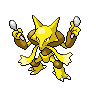
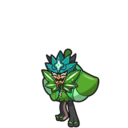

In [14]:
# Gym-badge stat tiles — the headline numbers at a glance. Text wears ink
# colors; the left accent stripe carries the model's color; the deck tile
# shows the REAL ace sprite (from the replay audit above).
from IPython.display import HTML, display


def _tile(accent: str, label: str, value: str, sub: str, img: str | None = None) -> str:
    sprite = (f'<img src="{img}" width="44" height="44" '
              f'style="image-rendering:pixelated;float:right;margin:-4px 0 0 8px;" '
              f'alt="deck ace sprite">' if img else "")
    return (
        f'<div style="flex:1;min-width:160px;border:1px solid {GRID};'
        f'border-left:5px solid {accent};border-radius:12px;'
        f'padding:12px 16px;background:{SURFACE};">{sprite}'
        f'<div style="font-size:11px;color:{INK2};text-transform:uppercase;'
        f'letter-spacing:.06em;">{label}</div>'
        f'<div style="font-size:22px;font-weight:700;color:{INK};'
        f'margin:2px 0;">{value}</div>'
        f'<div style="font-size:11px;color:{INK2};">{sub}</div></div>'
    )


if not episodes.empty:
    latest_score = (episodes.dropna(subset=["our_score"])
                    .groupby("submission")["our_score"].last())
    champ = latest_score.idxmax()
    live = episodes.loc[episodes["time"].idxmax(), "submission"]
    live_deck = DECK_META[DECKS[live]]
    last24 = episodes[episodes["time"]
                      > episodes["time"].max() - pd.Timedelta("24h")]
    tiles = [
        _tile(COLOR[champ], "🏆 Gym leader (top score)",
              f"{latest_score[champ]:.1f}", DEX[champ],
              DECK_META[DECKS[champ]]["sprite"]),
        _tile(live_deck["color"], "🎖️ Latest battler — deck",
              f"{live_deck['emoji']} {live_deck['ace']}",
              f"{MODELS[live]} · {DECKS[live]}.csv ({live_deck['type']})",
              live_deck["sprite"]),
        _tile(INK2, "⚔️ Battles fought", f"{len(episodes):,}",
              f"{int((episodes['win'] == 1).sum())} wins · all models"),
        _tile(INK2, "🕐 Last 24 h", f"{len(last24)} battles",
              f"win rate {last24['win'].mean():.0%}" if len(last24) else "—"),
    ]
    display(HTML('<div style="display:flex;gap:12px;flex-wrap:wrap;">'
                 + "".join(tiles) + "</div>"))
else:
    print("no episodes yet for any listed model")

,deck,episodes,wins,win_rate,latest_score,first_seen,last_seen
model,,,,,,,
M7.4a: solver-on (rules),Mega Lucario ex (lucario.csv),45,20,44.4%,500.0,Jul 11 22:15,Jul 12 19:23
M7.5: partial fixes (rules),Mega Lucario ex (lucario.csv),96,42,43.8%,502.5,Jul 12 17:00,Jul 17 06:29
M7.5: solver+5fixes (rules),Mega Lucario ex (lucario.csv),112,49,43.8%,548.6,Jul 12 20:34,Jul 17 18:54
M11: osv3_plan0c (neural),Mega Lucario ex (lucario.csv),40,14,35.0%,441.5,Jul 17 09:28,Jul 17 22:42
M14: osv3_plan2 (setup-plans),Mega Lucario ex (lucario.csv),36,15,41.7%,437.3,Jul 17 19:30,Jul 18 05:55
M15: osv3h_plan1 (hand-aware),Mega Lucario ex (lucario.csv),37,15,40.5%,422.8,Jul 17 23:12,Jul 18 20:19
M16: osv3o_plan1 (option-identity),Mega Abomasnow ex (kyogre.csv),44,20,45.5%,519.9,Jul 18 07:00,Jul 18 22:21
M18: osv3o_plan5 (value-teacher-fixed),Mega Abomasnow ex (kyogre.csv),41,17,41.5%,478.6,Jul 18 23:10,Jul 19 15:07
M18.1: osv3o_plan5+lucario (M18.1 deck fix),Mega Lucario ex (lucario.csv),44,21,47.7%,510.8,Jul 18 23:47,Jul 19 17:15

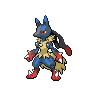
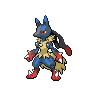
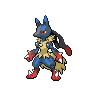
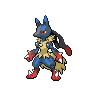
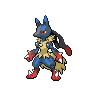
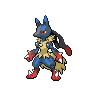
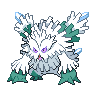
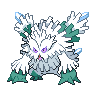
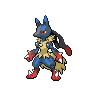
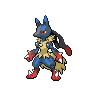
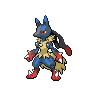
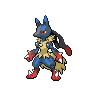
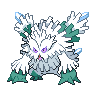
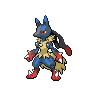
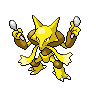
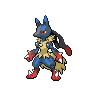
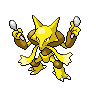
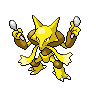
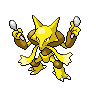
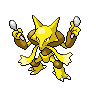
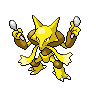
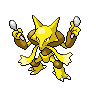
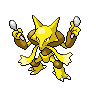
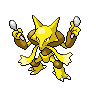
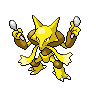
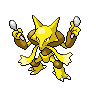
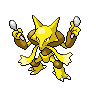
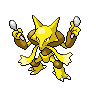
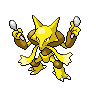
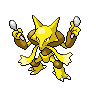
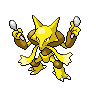
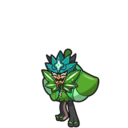

In [15]:
# 📕 Pokédex — one entry per shipped agent, now with its REAL deck (sprite +
# ace, from the replay audit). Also serves as the accessibility table-view
# for the charts below (win-rate bar = HP bar).
if not episodes.empty:
    summary = (episodes.groupby("submission", sort=False)
               .agg(episodes=("episode_id", "count"),
                    wins=("win", lambda w: int((w == 1).sum())),
                    win_rate=("win", "mean"),
                    latest_score=("our_score", lambda s: s.dropna().iloc[-1]
                                  if s.notna().any() else float("nan")),
                    first_seen=("time", "min"),
                    last_seen=("time", "max")))

    def _deck_cell(sid: int) -> str:
        meta = DECK_META[DECKS[sid]]
        img = (f'<img src="{meta["sprite"]}" width="28" height="28" '
               f'style="image-rendering:pixelated;vertical-align:middle;" '
               f'alt="">' if meta["sprite"] else meta["emoji"])
        return (f'{img} <span style="vertical-align:middle;">'
                f'{meta["ace"]} <span style="color:{INK2};">'
                f'({DECKS[sid]}.csv)</span></span>')

    summary.insert(0, "deck", summary.index.map(_deck_cell))
    summary.index = summary.index.map(MODELS)
    summary.index.name = "model"
    display(summary.style
            .set_caption("📕 Pokédex — battle records per shipped agent")
            .format({"win_rate": "{:.1%}", "latest_score": "{:.1f}",
                     "first_seen": "{:%b %d %H:%M}",
                     "last_seen": "{:%b %d %H:%M}"})
            .bar(subset=["win_rate"], color="#a7e0a7", vmin=0, vmax=1))
else:
    print("no episodes yet for any listed model")

In [16]:
# Chart 1 — leaderboard score over time (one line per model, single axis).
# Each line ends on its deck's ace sprite, so which deck a model played is
# readable straight off the chart (secondary encoding, never color-alone).
# Interactive: unified hover, range buttons + slider, legend click/isolate.
if not episodes.empty:
    scored = episodes.dropna(subset=["our_score"])
    span, pad = x_span_ms(scored["time"])
    y_span = max(scored["our_score"].max() - scored["our_score"].min(), 1.0)
    fig = go.Figure()
    sprites = []
    for sid, label in MODELS.items():
        d = scored[scored["submission"] == sid]
        if d.empty:
            continue
        fig.add_trace(go.Scatter(
            x=d["time"], y=d["our_score"],
            mode="lines+markers" if len(d) < 10 else "lines",
            name=DEX[sid], line=dict(color=COLOR[sid], width=2),
            marker=dict(size=6),
            hovertemplate="%{y:.1f} pts<extra>" + DEX[sid] + "</extra>"))
        # "caught!" marker on the newest point — a 2px surface ring keeps
        # overlapping line-ends separable, and shows through if a sprite
        # asset is missing.
        fig.add_trace(go.Scatter(
            x=d["time"].iloc[-1:], y=d["our_score"].iloc[-1:],
            mode="markers", showlegend=False, hoverinfo="skip",
            marker=dict(size=11, color=COLOR[sid],
                        line=dict(color=SURFACE, width=2))))
        sprites.append(ace_sprite_image(sid, d["time"].iloc[-1],
                                        d["our_score"].iloc[-1],
                                        span, y_span))
    fig.update_layout(
        title="⚔️ Leaderboard score over time",
        yaxis_title="score", height=480, hovermode="x unified",
        images=[im for im in sprites if im],
        xaxis=dict(
            range=[scored["time"].min(), scored["time"].max() + pad],
            rangeslider=dict(visible=True, thickness=0.07),
            rangeselector=dict(
                bgcolor=SURFACE, activecolor=GRID,
                buttons=[
                    dict(count=1, label="24h", step="day",
                         stepmode="backward"),
                    dict(count=3, label="3d", step="day",
                         stepmode="backward"),
                    dict(count=7, label="7d", step="day",
                         stepmode="backward"),
                    dict(step="all", label="all"),
                ])))
    fig.show()

In [17]:
# Chart 2 — rolling win rate, one line per model, each ending on its deck's
# ace sprite. The buttons switch the rolling window without re-running the
# cell (traces are precomputed); the sprites are precomputed per window too
# and swapped in the same update, so they never point at a stale line end.
WINDOWS, DEFAULT_WINDOW = (10, 25, 50), 25
if not episodes.empty:
    span, pad = x_span_ms(episodes["time"])
    fig = go.Figure()
    trace_window = []
    sprites = {w: [] for w in WINDOWS}
    for window in WINDOWS:
        for sid, label in MODELS.items():
            d = episodes[episodes["submission"] == sid]
            if len(d) < 5:
                continue
            roll = d["win"].rolling(window, min_periods=5).mean()
            fig.add_trace(go.Scatter(
                x=d["time"], y=roll, mode="lines",
                name=DEX[sid], visible=window == DEFAULT_WINDOW,
                line=dict(color=COLOR[sid], width=2),
                hovertemplate="%{y:.0%}<extra>" + DEX[sid] + "</extra>"))
            trace_window.append(window)
            sprite = ace_sprite_image(sid, d["time"].iloc[-1], roll.iloc[-1],
                                      span, 1.0)   # y-axis is fixed 0..1
            if sprite:
                sprites[window].append(sprite)
    fig.add_hline(y=0.5, line_color=INK2, line_width=1, line_dash="dot",
                  annotation_text="coin flip",
                  annotation_font_color=INK2)
    fig.update_layout(
        title="📈 Rolling win rate",
        yaxis=dict(title="win rate", range=[0, 1], tickformat=".0%"),
        xaxis=dict(range=[episodes["time"].min(),
                          episodes["time"].max() + pad]),
        height=460, hovermode="x unified",
        images=sprites[DEFAULT_WINDOW],
        updatemenus=[dict(
            type="buttons", direction="right",
            x=1, xanchor="right", y=1.18, yanchor="top",
            active=WINDOWS.index(DEFAULT_WINDOW),
            font=dict(color=INK2), bgcolor=SURFACE,
            buttons=[dict(label=f"{w}-battle window", method="update",
                          args=[{"visible": [t == w for t in trace_window]},
                                {"images": sprites[w]}])
                     for w in WINDOWS])])
    fig.show()

In [18]:
# Chart 3 — battle log: every Kaggle episode as one Pokéball on its model's
# row. Filled ball = win, hollow = loss, dotted = draw (shape, not
# color-alone, carries the result). Hover a ball for the battle report.
SYMBOL = {1.0: "circle", 0.5: "circle-open-dot", 0.0: "circle-open"}
FLAVOR = {1.0: "WIN — it's super effective!",
          0.5: "DRAW — both trainers blacked out",
          0.0: "LOSS — our agent fainted"}
if not episodes.empty:
    fig = go.Figure()
    for sid, label in MODELS.items():
        d = episodes[episodes["submission"] == sid]
        if d.empty:
            continue
        fig.add_trace(go.Scatter(
            x=d["time"], y=[DEX[sid]] * len(d), mode="markers",
            showlegend=False,
            marker=dict(color=COLOR[sid], size=9,
                        symbol=d["win"].map(SYMBOL),
                        line=dict(width=1.5, color=COLOR[sid])),
            customdata=list(zip(d["win"].map(FLAVOR),
                                d["our_reward"], d["opp_reward"],
                                d["our_score"])),
            hovertemplate=("%{customdata[0]}<br>"
                           "reward %{customdata[1]} vs %{customdata[2]} · "
                           "score %{customdata[3]:.1f}<br>"
                           "%{x|%b %d %H:%M}<extra>" + label + "</extra>")))
    fig.update_layout(
        title="🔴 Battle log — ● win · ○ loss · ◎ draw",
        height=400,
        yaxis=dict(autorange="reversed", automargin=True, title=None),
        xaxis=dict(title=None))
    fig.show()

In [19]:
# Chart 4 — 🎴 deck performance: rolling win rate pooled across every model
# that shipped the deck (deck resolved from replays, cell 2). Validated
# colors; the ace sprite rides the line end as the direct label, so identity
# is never color-alone. M19 focus point: did the M16+ switch from lucario to
# the water deck move the leaderboard? M24 adds the clone deck (🧬).
WINDOW_DECK = 25
if not episodes.empty:
    episodes["deck"] = episodes["submission"].map(DECKS)
    fig = go.Figure()
    for deck_key in ("lucario", "kyogre", "clone54618168", "alakazam_v2", "ogerpon"):
        meta = DECK_META[deck_key]
        d = (episodes[episodes["deck"] == deck_key]
             .sort_values("time").reset_index(drop=True))
        if len(d) < 5:
            continue
        roll = d["win"].rolling(WINDOW_DECK, min_periods=5).mean()
        name = f"{meta['emoji']} {meta['ace']} · {len(d)} battles"
        fig.add_trace(go.Scatter(
            x=d["time"], y=roll, mode="lines", name=name,
            line=dict(color=meta["color"], width=2),
            hovertemplate="%{y:.0%}<extra>" + name + "</extra>"))
        if meta["sprite"]:                      # ace sprite = end-of-line label
            fig.add_layout_image(
                source=meta["sprite"], xref="paper", yref="y",
                x=1.0, y=float(roll.iloc[-1]), xanchor="left",
                yanchor="middle", sizex=0.09, sizey=0.22, layer="above")
    fig.add_hline(y=0.5, line_color=INK2, line_width=1, line_dash="dot",
                  annotation_text="coin flip", annotation_font_color=INK2)
    # models switching decks over time = a natural A/B; mark the switch
    switch = episodes[episodes["deck"] == "kyogre"]["time"].min()
    if pd.notna(switch):
        fig.add_vline(x=switch, line_color=GRID, line_width=1,
                      line_dash="dash")
        fig.add_annotation(x=switch, y=1.02, yref="paper", showarrow=False,
                           text="first water-deck ship (M16)",
                           font=dict(size=10, color=INK2))
    fig.update_layout(
        title="🎴 Deck performance — rolling win rate "
              f"({WINDOW_DECK}-battle window, pooled across models)",
        yaxis=dict(title="win rate", range=[0, 1], tickformat=".0%"),
        height=440, hovermode="x unified",
        margin=dict(r=80))                       # room for the sprites
    fig.show()